Task 1: Implementation of MCP Neurons

To implement the "AND" and "OR" Boolean functions using the MCP neuron, we need to aggregate the inputs and apply a handcrafted threshold.

**Code Implementation for "AND" and "OR"**

In [1]:
import numpy as np

def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)
    state_neuron = []

    # Element-wise addition of two input arrays
    for i in range(len(X1)):
        sum_inputs = X1[i] + X2[i]
        # Append 1 if sum is >= Threshold, else 0
        if sum_inputs >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)
    state_neuron = []

    # Element-wise addition of two input arrays
    for i in range(len(X1)):
        sum_inputs = X1[i] + X2[i]
        # Append 1 if sum is >= Threshold, else 0
        if sum_inputs >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

# --- Sample Usages ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# For AND gate, both inputs must be 1, so the sum must be 2. Threshold = 2.
result_and = MCP_Neurons_AND(X1, X2, T=2)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold 2: {result_and}")

# For OR gate, at least one input must be 1, so the sum must be >= 1. Threshold = 1.
result_or = MCP_Neurons_OR(X1, X2, T=1)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold 1: {result_or}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]
Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**3.2.1 Answers to Questions**

**Question - 1: Limitations of MCP - Neurons.**

1. The MCP model is a highly
simplified representation of biological neurons.

2. It relies on manually handcrafted threshold values and does not feature an adaptive learning process.

3. It processes all inputs with equal weight (no concept of variable weights indicating the importance of specific inputs).

4. It can only compute linearly separable logic functions.

**Question - 2: Solving the XOR function using MCP Neuron.**

Ans: You cannot solve the XOR (Exclusive OR) function using a single MCP neuron. The XOR function is not linearly separable, meaning no single line (or hyperplane) can separate the true outputs (1) from the false outputs (0) on a graph. To solve XOR, you would need to combine multiple MCP neurons in a multi-layered structure (e.g., combining AND, OR, and NOT logic gates).

**Task 2: Perceptron Algorithm for 0 vs 1 Classification**

The Perceptron extends the MCP model by introducing learnable weights and an algorithmic way to adjust them.

Understanding the Dataset & Initialization

**Question - 1 & 2: What does the shape of X represent?**

Ans: The shape of X represents the dimensions of the feature matrix. The rows represent the total number of image samples, and the columns represent the individual features. For the MNIST dataset, since each image is 28x28 pixels, there are 784 features representing the pixel intensities.

**Question - 3: What does the weights array represent in this context?**

Ans: The weights array represents the learnable parameters of the perceptron model. There is one weight for every input feature (pixel). The magnitude and sign of a specific weight dictate how strongly that particular pixel influences the final decision boundary.

**Question - 4: Why are we initializing the weights to zero? What effect could this have?**

Ans: Initializing to zero means the perceptron starts with no prior assumptions or bias toward any specific feature. In a simple single-layer perceptron, this works perfectly fine because the learning rule will adjust the weights strictly based on the prediction errors encountered during the first epoch.

**Code Implementation: Decision Function & Training**

In [2]:
def decision_function(X, weights, bias):
    """Compute the predicted labels for the input data."""
    # Compute weighted sum
    predictions = np.dot(X, weights) + bias

    # Activation function (step function): y_pred = 1 if z >= 0 else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """Train the perceptron using the Perceptron Learning Algorithm."""
    for epoch in range(epochs):
        for i in range(len(X)):
            # Step 1: Compute aggregated input
            z = np.dot(X[i], weights) + bias

            # Step 2: Apply threshold function
            y_pred = 1 if z >= 0 else 0

            # Step 3: Update weights if misclassified
            if y_pred != y[i]:
                # Error is (true label - predicted label)
                error = y[i] - y_pred
                # Update rule
                weights += learning_rate * error * X[i]
                bias += learning_rate * error

    # Calculate final accuracy after training
    y_pred_final = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_final == y)

    return weights, bias, accuracy

**Answers to Training Questions**

**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?**

Ans: This computes the net weighted input (often denoted as $z$), which is the sum of each feature multiplied by its respective weight, plus the bias term.

**Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?**

Ans: When wrong, the algorithm calculates the error and adjusts the weights to reduce the prediction error. The weights are updated by adding the product of the learning rate, the error $(y - \hat{y})$, and the input feature $x_i$. The bias is updated similarly but without multiplying by the input feature.

**Question - 7: Why is the final accuracy important, and what do you expect it to be?**

Ans: Final accuracy measures how well the perceptron's decision boundary separates the two classes. For digits 0 and 1, we expect the accuracy to be exceptionally high (close to 1.0 or 100%) because the shapes of a '0' (a loop) and a '1' (a straight line) are highly distinct and mostly linearly separable.

**Question - 8: What does misclassified_idx store, and how is it used?**

Ans: It stores the array indices of the input samples where the model's predicted label did not match the true label. It is used to slice the dataset so we can plot and visually inspect the specific images the model struggled with.

**Question - 9: How do you interpret the result if the output is "All images were correctly classified!"?**

Ans: This indicates that the dataset is perfectly linearly separable. The perceptron successfully found a hyperplane that completely isolates all the '0's from the '1's without a single error.

**Task 3: Perceptron Algorithm for 3 vs 5 Classification**

To complete Task 3, you will follow the exact same programmatic steps as Task 2, but point your pandas dataframe to mnist_3_and_5.csv.

**Code execution flow:**

Final Accuracy for 3 vs 5: 0.1124


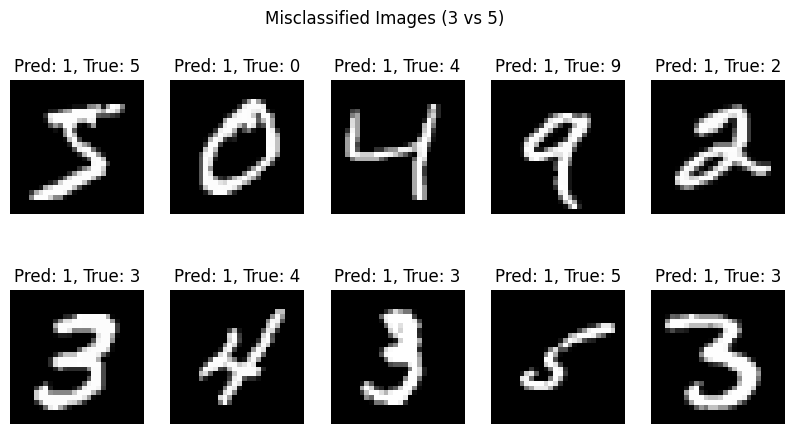

In [8]:
# 1. Load the dataset
df_3_5 = pd.read_csv("/content/mnist_train.csv")
X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

# 2. Initialize weights and bias
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0

# 3. Train the model
weights_35, bias_35, accuracy_35 = train_perceptron(X_35, y_35, weights_35, bias_35, learning_rate=0.1, epochs=100)
print(f"Final Accuracy for 3 vs 5: {accuracy_35:.4f}")

# 4. Visualize misclassifications
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)
misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]

if len(misclassified_idx_35) > 0:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_35[idx]}, True: {y_35[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

**Conclusion for 3 vs 5 Classification:**

Ans: Unlike digits 0 and 1, the digits 3 and 5 are structurally very similar (they both share curved bottoms and straight horizontal components at the top). Because a Perceptron is strictly a linear classifier, it cannot capture the complex, non-linear geometric variations required to separate messy 3s from messy 5s. Consequently, you will notice a lower final accuracy compared to the 0 vs 1 task, and the plotted misclassified images will generally be sloppily written digits where the defining loops and strokes are ambiguous.